In [1]:
import os 
import sys
sys.path.append("../../")


import numpy as np
import torch
import torch.nn as nn

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader
from vi_rnn.datasets import Reaching, Reaching_Teacher
from vi_rnn.mock_nm_dataset import * 
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model, load_model
from vi_rnn.evaluation import predict_X, compute_KL_divergence 
from py_rnn.default_params import get_default_params

%matplotlib inline

In [2]:
data_dir = '../../data/nmrnn/'
model_dir = '../../models/students/'
cuda = False  # toggle if GPU is available
device = 'cpu'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

train_batches = 10

### Load dataset

In [3]:
x = np.load(''.join([data_dir, 'x_fr.npy'])) # population firing rates
x_train, x_test = x[:train_batches, :, :], x[train_batches:, :, :]

y = np.load(''.join([data_dir, 'y.npy'])) # Teacher output
y_train, y_test = y[:train_batches, :, :], y[train_batches:, :, :]

task_label = np.load(''.join([data_dir, 'output_arr.npy']))
task_label_train, task_label_test = task_label[:train_batches, :, :], \
    task_label[train_batches:, :, :]

z = np.load(''.join([data_dir, 'z_fr.npy'])) # neuromodulator latent states 

task_input = np.load(''.join([data_dir, 'input_arr.npy'])) # MWG task input 
task_input_train, task_input_test = task_input[:train_batches, :, :], \
    task_input[train_batches:, :, :]

neuromod_readout_weights = np.load(''.join([data_dir, 'nm_readout_weights.npy']))
neuromod_readout_biases = np.load(''.join([data_dir, 'nm_readout_biases.npy']))

In [4]:
# transform to torch tensors and copy to gpu 
x_train, x_test = torch.from_numpy(x_train).to(device).to(torch.float32), \
    torch.from_numpy(x_test).to(device).to(torch.float32)
y_train, y_test = torch.from_numpy(y_train).to(device), torch.from_numpy(y_test).to(device)

z = torch.from_numpy(z).to(device).to(torch.float32)

task_input_train, task_input_test = torch.from_numpy(task_input_train).to(device).to(torch.float32), \
    torch.from_numpy(task_input_test).to(device).to(torch.float32)
task_label_train, task_label_test = torch.from_numpy(task_label).to(device).to(torch.float32), \
    torch.from_numpy(task_label_test).to(device).to(torch.float32)

neuromod_readout_weights = torch.from_numpy(neuromod_readout_weights).to(device) 
neuromod_readout_biases = torch.from_numpy(neuromod_readout_biases).to(device) 

In [5]:
# compute neuromodulator signals s from z 
s = torch.sigmoid(torch.matmul(z, neuromod_readout_weights.T)) + neuromod_readout_biases
s_train, s_test = s[:train_batches, :, :].to(device), s[train_batches:, :, :].to(device)

In [6]:
# Initialise VI / student setup

dim_z = 3
dim_N = 100
dim_x = 100
dim_u = 3
bs = 10
n_epochs = 10000
wandb = True
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

task_params = {
    "dur": 100,
    "n_trials": x_train.size(0),
    "out": "currents",
    "n_neurons": 100,
    "non_lin": nn.Tanh(),
    "name": "mock_training"
}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.05,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "tanh",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_rates": task_params['out'],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",
    "neuromodulators": False, 
    "rank_scaling_params": False,
}


training_params = {
    "lr": 0.0002,
    "step_size": 300, 
    "gamma": 0.9,
    "lr_end": 1e-5,
    "opt_eps": 1e-8,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 100000,
    "batch_size": bs,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": True,
    "smooth_at_eval": False,
    "neuromodulators": False,
}

# initialise encoder
enc_params = {
    **enc_params,
    "init_kernel_sizes": [21, 11, 1],
    "nonlinearity": "gelu",
    "n_channels": [64, 64],
    "init_scale": 0.1,
    "constant_var": False,
    "n_hidden": 64,
    "strides": [1, 1, 1],
    "dilations": [1, 1, 1],
    "padding": "same",
    "padding_mode": "circular",
}

VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal": True,
}


In [7]:
# x_train = x_train.permute(2, 1, 0)
training_task = MockDataset(task_params, x_train, task_input_train, s_train)
eval_task = MockDataset(task_params, x_test, task_input_test, s_test)
vae = VAE(VAE_params)

using tanh activation
using uniform init
weight scaler 1


In [14]:
train_VAE(
    vae,
    training_params,
    training_task,
    eval_task=eval_task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Training on : cpu


wandb: Currently logged in as: kaleab-belay (kaleab-belay-icm). Use `wandb login --relogin` to force relogin


Learning rate decay factor 0.9997004716402234
----------------------------------------------------------------------------------------------------
Batch loss: 16247.154296875
loss: 16247.154296875
batch_h_loss: -7.1986284255981445
batch_ll: -16247.154296875
batch_ll_x: -16241.4140625
epoch 1 loss: 16247.1543, ll: -16247.1543, ll_x: 16241.4141, ll_z: -2.2885 H: 7.1986, alpha: 0.24, lr: 0.000200, N_z: 0.0506, N_x: 0.1017
----------------------------------------------------------------------------------------------------
Batch loss: 14690.533203125
loss: 14690.533203125
batch_h_loss: -7.1691179275512695
batch_ll: -14690.533203125
batch_ll_x: -14685.107421875
epoch 2 loss: 14690.5332, ll: -14690.5332, ll_x: 14685.1074, ll_z: -2.5175 H: 7.1691, alpha: 0.23, lr: 0.000200, N_z: 0.0520, N_x: 0.1033
----------------------------------------------------------------------------------------------------
Batch loss: 13416.640625
loss: 13416.640625
batch_h_loss: -7.156203269958496
batch_ll: -13416.640

[]

In [9]:
save_model(vae, training_params, task_params, name=model_dir + "/mock_student_network_1")

'../../models/students//mock_student_network_1'

In [8]:
# load model 
model, vae_params, task_params, training_params = load_model(name=model_dir + "/mock_training_Inv_Obs_LRRNN_Z_Date_32024_10_02_T_17_07_31")

using tanh activation
using uniform init
weight scaler 1


c:\Users\kaleab.belay\Documents\Project\smc_rnns\train_scripts\student_teacher\../..\vi_rnn\saving.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state

In [13]:
X_pred = predict_X(
    vae, 
    task_params['dur'],
    x_train[0].T,
    task_input_train[0].T.unsqueeze(0),
    # s_test[-1].T.unsqueeze(0),
    s=None,
    neuromodulators=False
)

torch.Size([100, 100])
torch.Size([1, 3, 100, 1])


In [15]:
x.shape

(24, 100, 100)

C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_3232\150348015.py:10: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


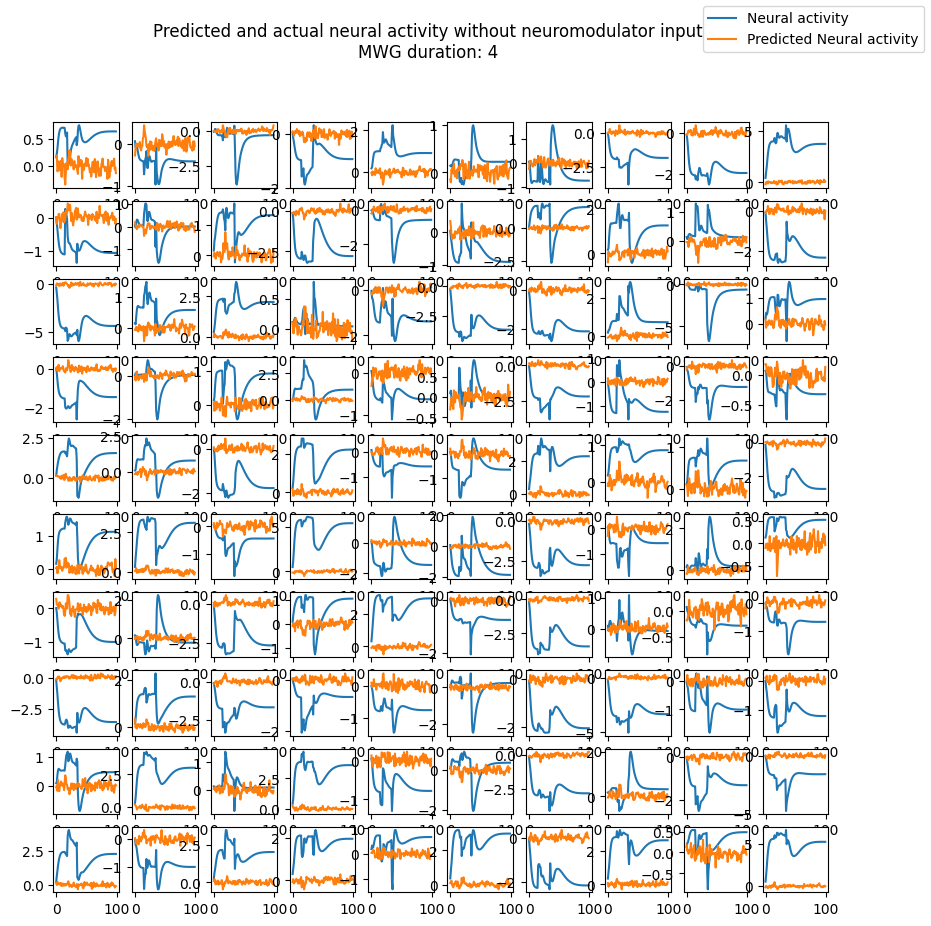

In [14]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(10, 10, figsize=(10, 10))
for i in range(task_params["n_neurons"]):
    idx_i = i // 10
    idx_j = i % 10
    ax[idx_i, idx_j].plot(x_train[0, :, i], label=f'Neural activity')
    ax[idx_i, idx_j].plot(X_pred[0, i, :], label=f'Predicted Neural activity')

fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
fig.suptitle("Predicted and actual neural activity without neuromodulator input\nMWG duration: 4")
fig.savefig("no_neuromodulator_plot_dur_4.png")
plt.show()

In [ ]:
training_params["neuromodulators"] = False 
prior_params["neuromodulators"] = False

# x_train = x_train.permute(2, 1, 0)
training_task = MockDataset(task_params, x_train, task_input_train, s_train)
eval_task = MockDataset(task_params, x_test, task_input_test, s_test)
vae = VAE(VAE_params)

train_VAE(
    vae,
    training_params,
    training_task,
    eval_task=eval_task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)